<a href="https://colab.research.google.com/github/thiendoan0401-hue/018793021_CMPE188_Lab2/blob/main/LinearRegressionComplete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Credits: Part of this notebook was generated by Google Colab's AI agent

**Name**: Thien Doan

SJSU ID: 018793021

GitHub link: https://github.com/f26-sjsu-cmpe188/Iris/blob/3b0021abb7b475f426bcfa07937998c4288098e0/Iris_ClassDemo.ipynb$0

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import random

## Generates N random points for logistic regression on a line w
def generate_lr(N=20,w0=0,w1=1):
    n = 0
    X1 = []
    Y = []
    while(n < N):
        x1 = random.uniform(-10,10)
        x2 = random.uniform(-1,1)
        y = w0 + w1*x1 + x2
        X1.append(x1)
        Y.append(y)
        n += 1
    data = [np.array([1,X1[i],Y[i]]) for i in range(N)]
    return data

In [ ]:
f_w0, f_w1 = 1, 1
N = 50
data = generate_lr(N, f_w0, f_w1)

In [ ]:
def abline(slope, intercept, color='b', label=None):
    """Plot a line from slope and intercept"""
    axes = plt.gca()
    x_vals = np.array(axes.get_xlim())
    y_vals = intercept + slope * x_vals
    plt.plot(x_vals, y_vals, '--', label=label, c=color)

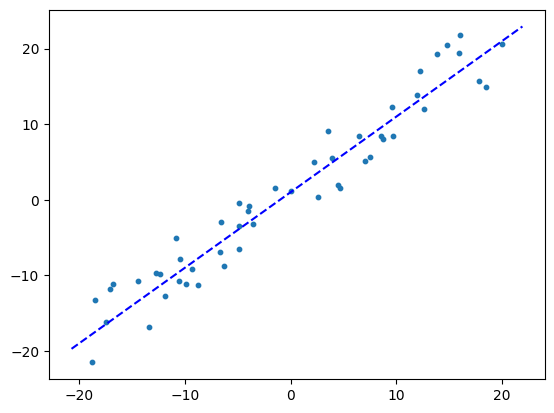

In [ ]:
X1 = [i[1] for i in data]
Y  = [i[2] for i in data]
markers = [] #'o' or '+'
colors = [] # 'b' or 'r'
cnt = 0
plt.scatter(X1,Y, s = 10)

abline(f_w1,f_w0)
plt.show()

In [ ]:
X = [[i[0], i[1]] for i in data]
Y  = [i[2] for i in data]

In [ ]:
np.array(X).shape

(50, 2)

In [ ]:
np.array(Y).shape

(50,)

In [ ]:
XtX = np.matmul(np.transpose(X), X)
XtX.shape

(2, 2)

In [ ]:
XtX_inv = np.linalg.inv(XtX)
XtX_inv.shape
XtX_inv

array([[2.00468321e-02, 8.67111129e-05],
       [8.67111129e-05, 1.60548321e-04]])

In [ ]:
X_pi = np.matmul(XtX_inv, np.transpose(X))
X_pi

array([[ 2.14330707e-02,  2.11415210e-02,  2.02724452e-02,
         2.07018785e-02,  1.94694935e-02,  1.91912569e-02,
         2.16503517e-02,  1.84475005e-02,  1.89483005e-02,
         1.89812395e-02,  1.91444964e-02,  1.97037697e-02,
         2.04552035e-02,  2.12480491e-02,  2.08040946e-02,
         1.85891555e-02,  1.96287905e-02,  2.14309161e-02,
         2.07922180e-02,  1.84205344e-02,  1.99202474e-02,
         1.91119243e-02,  2.06539608e-02,  2.04340855e-02,
         2.03507730e-02,  1.95049308e-02,  1.90203549e-02,
         2.02390342e-02,  2.13255739e-02,  1.87946046e-02,
         1.94742129e-02,  2.17789108e-02,  2.10841611e-02,
         2.15946871e-02,  1.97369035e-02,  1.91364414e-02,
         1.92374632e-02,  1.92854568e-02,  2.06038450e-02,
         1.88869154e-02,  2.11076209e-02,  2.03879059e-02,
         1.96282266e-02,  1.85718669e-02,  1.96244769e-02,
         1.85343127e-02,  2.08743731e-02,  1.97012648e-02,
         2.00530166e-02,  2.08881631e-02],
       [ 2.65

In [ ]:
w = np.matmul(X_pi, Y)
w

array([1.22001763, 0.9814572 ])

Plot the final hypothesis with the target and the data points

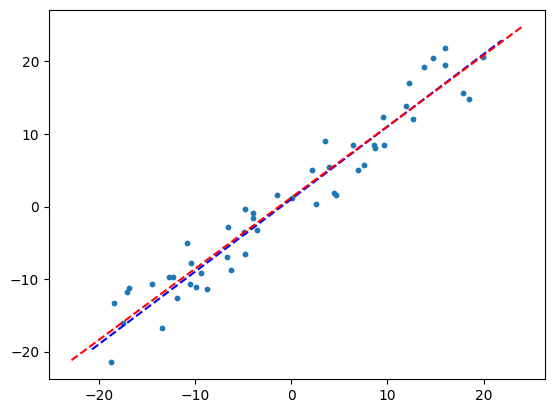

In [ ]:
X1 = [i[1] for i in data]
Y  = [i[2] for i in data]
plt.scatter(X1,Y, s = 10)

abline(f_w1,f_w0)
abline(w[1],w[0], color='r')
plt.show()

In [ ]:
Y_pred = np.matmul(X, w)
np.sum(np.square(Y_pred-Y))

np.float64(412.7009482218244)

In [ ]:
w_other = [3, 2]
Y_other = np.matmul(X, w_other)
np.sum(np.square(Y_other-Y))

np.float64(6950.119899426251)

What about the test data set?

In [ ]:
#50 test samples
testdata = generate_lr(50, f_w0, f_w1)
X_test = [[i[0], i[1]] for i in testdata]
Y_test  = [i[2] for i in testdata]
Y_pred_test = np.matmul(X_test, w)
np.sum(np.square(Y_pred_test-Y_test))

np.float64(537.0224257813406)

In [ ]:
Y_pred_test_target = np.matmul(X_test, [1, 1])
np.sum(np.square(Y_pred_test_target-Y_test))

np.float64(532.3345002597827)

Library implementation of linear regression




In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
model = LinearRegression()
model.fit(np.array(X)[:, 1].reshape(-1, 1), Y)

LinearRegression()

### Learned coefficients from `sklearn`

In [ ]:
print(f"Intercept (w0): {model.intercept_}")
print(f"Coefficient (w1): {model.coef_[0]}")

Intercept (w0): 1.220017632275953
Coefficient (w1): 0.9814571955117682


### Sum of squared errors on training data (`sklearn`)

In [ ]:
Y_pred_sklearn = model.predict(np.array(X)[:, 1].reshape(-1, 1))
np.sum(np.square(Y_pred_sklearn - Y))

np.float64(412.7009482218245)

### Sum of squared errors on test data (`sklearn`)

In [ ]:
Y_pred_test_sklearn = model.predict(np.array(X_test)[:, 1].reshape(-1, 1))
np.sum(np.square(Y_pred_test_sklearn - Y_test))

np.float64(537.0224257813408)

### Comparison of Analytical and `sklearn` Results

In [ ]:
print(f"Analytical Solution Coefficients: w0 = {w[0]:.4f}, w1 = {w[1]:.4f}")
print(f"Sklearn Coefficients:           w0 = {model.intercept_:.4f}, w1 = {model.coef_[0]:.4f}")

print(f"\nAnalytical Solution SSE (Training): {np.sum(np.square(np.matmul(X, w) - Y)):.4f}")
print(f"Sklearn SSE (Training):             {np.sum(np.square(model.predict(np.array(X)[:, 1].reshape(-1, 1)) - Y)):.4f}")

print(f"\nAnalytical Solution SSE (Test): {np.sum(np.square(np.matmul(X_test, w) - Y_test)):.4f}")
print(f"Sklearn SSE (Test):             {np.sum(np.square(model.predict(np.array(X_test)[:, 1].reshape(-1, 1)) - Y_test)):.4f}")

Analytical Solution Coefficients: w0 = 1.2200, w1 = 0.9815
Sklearn Coefficients:           w0 = 1.2200, w1 = 0.9815

Analytical Solution SSE (Training): 412.7009
Sklearn SSE (Training):             412.7009

Analytical Solution SSE (Test): 537.0224
Sklearn SSE (Test):             537.0224


### Plotting Analytical vs. `sklearn` Regression Lines

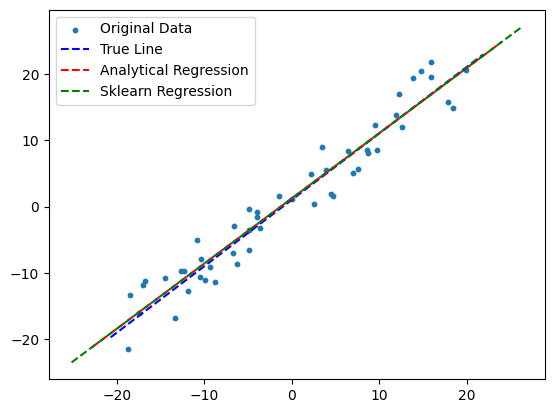

In [ ]:
plt.scatter(X1, Y, s=10, label='Original Data')
abline(f_w1, f_w0, color='b', label='True Line')
abline(w[1], w[0], color='r', label='Analytical Regression')
abline(model.coef_[0], model.intercept_, color='g', label='Sklearn Regression')
plt.legend()
plt.show()

a. Change the range of the data points and noise levels and experiment with the linear regression decision boundary line for the test data set - exactly the way we did for the training dataset.

- Original function (1)

x1 = random.uniform(-10,10)

x2 = random.uniform(-1,1)

The data points are close to the regression line.


- Increase noise level (2)

x1 = random.uniform(-10,10)

x2 = random.uniform(-5,5)

The data points are more spread out compared with case (1).


- Increase Range data (3)

x1 = random.uniform(-20,20)

x2 = random.uniform(-1,1)

The data covers a wider range, making the linear relationship clearer.


- Increase noise level (4)

x1 = random.uniform(-20,20)

x2 = random.uniform(-5,5)

The data points are more spread out compared with case (3).



Higher noise generally reduces model performance. A larger data range can make the linear relationship clearer when the noise stays the same.

b. Find the error in the linear regression implementation and fix it.



In [ ]:
XtX = np.matmul(X, np.transpose(X))
XtX.shape

(50, 50)

Change to

In [ ]:
XtX = np.matmul(np.transpose(X),X)
XtX.shape

(2, 2)

c. Compare the performance of your linear regression model with the library implementation. What do you observe if you change the dataset?

In all cases, both my linear regression model and the library implementation produce the same results. When the dataset changes, both models adjust and still produce nearly identical regression lines and errors.



d. Would you be able to use the metrics we studied in logistic regression for linear regression as well? Why? Add a comment on this question to the notebook.

No. Because metrics such as accuracy, precision, and recall are designed for classification problems where the output is a discrete class. Linear regression predicts continuous numerical values, so these classification metrics are not appropriate.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
mean_squared_error(Y_pred_test, Y_test)

10.740448515626813

In [ ]:
r2_score(Y_pred_test, Y_test)

0.9112044246730142

In [ ]:
accuracy_score(Y_pred_test, Y_test)

ValueError: continuous is not supported